# Notebook 02: Exploratory Data Analysis

All visualisations are insight-driven, well-labelled, and tied directly to pricing implications.

Key questions answered here:
1. How does demand vary intraday, by day-of-week, and across peak/shoulder/off-peak periods?
2. What are the differences between ACN (workplace fleet) and UrbanEV (public urban) charging?
3. Where is utilisation consistently high (congestion risk) or low (underutilisation)?
4. What is the preliminary price–demand relationship in UrbanEV?

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..') / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

OUT_DATA = Path('..') / 'data_processed'
OUT_FIG  = Path('..') / 'outputs' / 'figures'
OUT_FIG.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
COLORS = {'peak': '#d62728', 'shoulder': '#ff7f0e', 'off_peak': '#2ca02c',
          'acn': '#1f77b4', 'uev': '#17becf'}

acn_h = pd.read_parquet(OUT_DATA / 'acn_station_hour.parquet')
acn_h['slot'] = pd.to_datetime(acn_h['slot'], utc=True)
uev = pd.read_parquet(OUT_DATA / 'urbanev_featured.parquet')
uev['datetime'] = pd.to_datetime(uev['datetime'])

print(f'ACN station-hour: {acn_h.shape}')
print(f'UrbanEV featured: {uev.shape}')

ACN station-hour: (14839, 19)
UrbanEV featured: (2134080, 42)


## 1. Intraday Demand Patterns

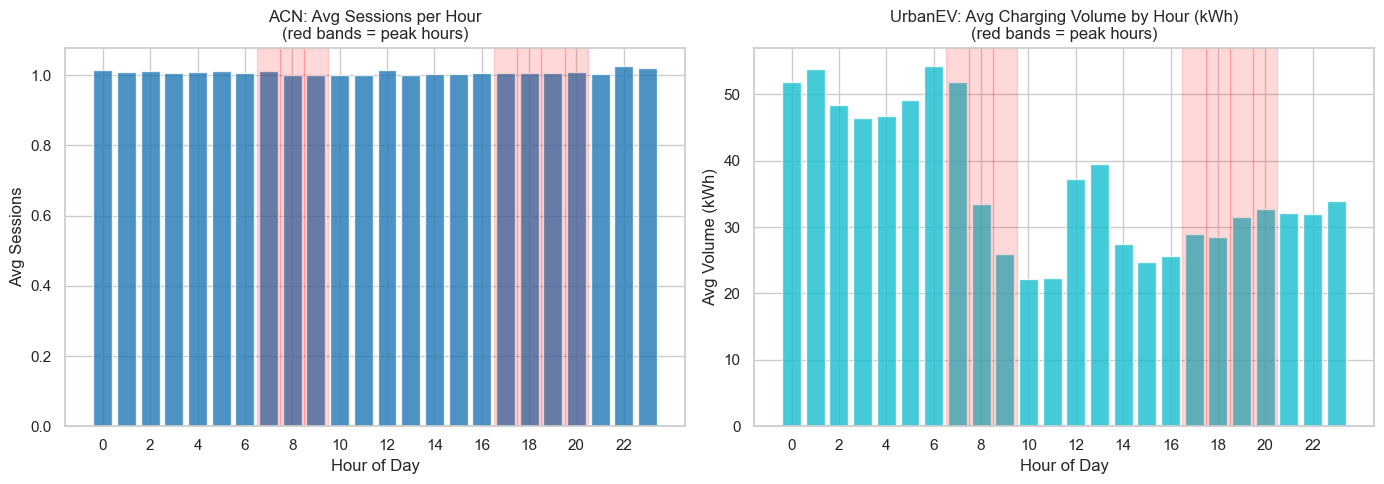

Pricing implication: Demand concentrates in morning and evening peaks.
Surge pricing during peak hours can redistribute load and capture higher revenue.
Discounts in the 0–6 AM window can activate dormant charger capacity.


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ACN: sessions by hour
acn_hour = acn_h.groupby('hour')['sessions'].mean()
axes[0].bar(acn_hour.index, acn_hour.values, color=COLORS['acn'], alpha=0.8)
for h in [7, 8, 9, 17, 18, 19, 20]:
    axes[0].axvspan(h-0.5, h+0.5, alpha=0.15, color='red')
axes[0].set_title('ACN: Avg Sessions per Hour\n(red bands = peak hours)', fontsize=12)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Avg Sessions')
axes[0].set_xticks(range(0, 24, 2))

# UrbanEV: avg volume by hour
uev_hour = uev.groupby('hour')['volume'].mean()
axes[1].bar(uev_hour.index, uev_hour.values, color=COLORS['uev'], alpha=0.8)
for h in [7, 8, 9, 17, 18, 19, 20]:
    axes[1].axvspan(h-0.5, h+0.5, alpha=0.15, color='red')
axes[1].set_title('UrbanEV: Avg Charging Volume by Hour (kWh)\n(red bands = peak hours)', fontsize=12)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Avg Volume (kWh)')
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig(OUT_FIG / 'eda_intraday.png', dpi=150)
plt.show()
print('Pricing implication: Demand concentrates in morning and evening peaks.\nSurge pricing during peak hours can redistribute load and capture higher revenue.\nDiscounts in the 0–6 AM window can activate dormant charger capacity.')

## 2. Weekday vs Weekend Patterns

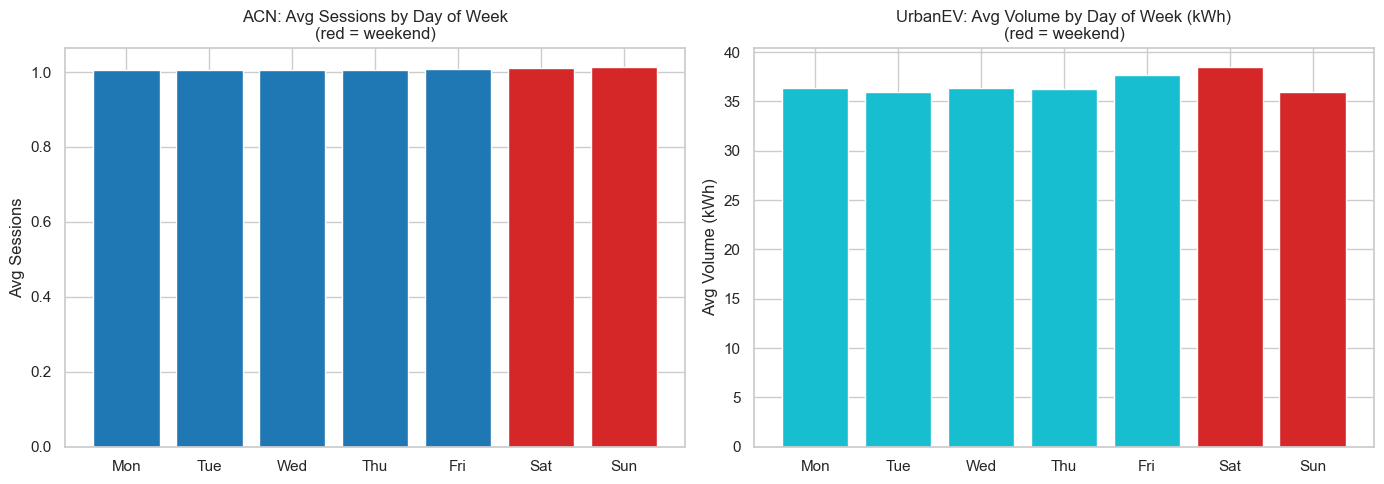

Pricing implication: ACN shows a strong weekday peak (workplace fleet charging).
Weekend discounts can improve off-peak utilisation without sacrificing weekday revenue.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

# ACN
acn_dow = acn_h.groupby('dow')['sessions'].mean()
bars = axes[0].bar(acn_dow.index, acn_dow.values,
                   color=[COLORS['peak'] if d >= 5 else COLORS['acn'] for d in acn_dow.index])
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(day_labels)
axes[0].set_title('ACN: Avg Sessions by Day of Week\n(red = weekend)', fontsize=12)
axes[0].set_ylabel('Avg Sessions')

# UrbanEV
uev_dow = uev.groupby('dow')['volume'].mean()
axes[1].bar(uev_dow.index, uev_dow.values,
            color=[COLORS['peak'] if d >= 5 else COLORS['uev'] for d in uev_dow.index])
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_labels)
axes[1].set_title('UrbanEV: Avg Volume by Day of Week (kWh)\n(red = weekend)', fontsize=12)
axes[1].set_ylabel('Avg Volume (kWh)')

plt.tight_layout()
plt.savefig(OUT_FIG / 'eda_weekday_weekend.png', dpi=150)
plt.show()
print('Pricing implication: ACN shows a strong weekday peak (workplace fleet charging).\nWeekend discounts can improve off-peak utilisation without sacrificing weekday revenue.')

## 3. Utilisation Distribution: Peak vs Shoulder vs Off-Peak

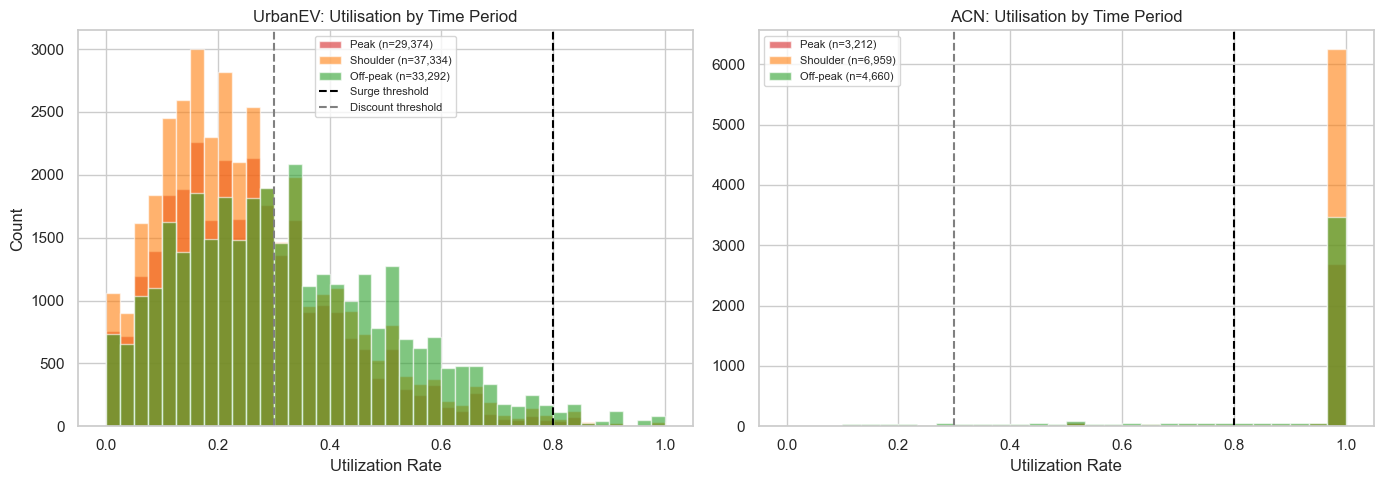

Peak      : surge-eligible 0.7% | discount-eligible 65.3%
Shoulder  : surge-eligible 0.8% | discount-eligible 66.8%
Off-peak  : surge-eligible 1.7% | discount-eligible 50.2%


In [4]:
from features import PEAK_HOURS, OFF_PEAK_HOURS

def label_period(h):
    if h in PEAK_HOURS: return 'Peak'
    if h in OFF_PEAK_HOURS: return 'Off-peak'
    return 'Shoulder'

uev['period_label'] = uev['hour'].apply(label_period)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# UrbanEV utilisation by period
period_order = ['Peak', 'Shoulder', 'Off-peak']
period_colors = [COLORS['peak'], COLORS['shoulder'], COLORS['off_peak']]
uev_sample = uev[uev['utilization_rate'].notna()].sample(100000, random_state=42)
for i, (period, color) in enumerate(zip(period_order, period_colors)):
    data = uev_sample[uev_sample['period_label'] == period]['utilization_rate']
    axes[0].hist(data, bins=40, alpha=0.6, color=color, label=f'{period} (n={len(data):,})')
axes[0].axvline(0.8, color='black', linestyle='--', lw=1.5, label='Surge threshold')
axes[0].axvline(0.3, color='grey', linestyle='--', lw=1.5, label='Discount threshold')
axes[0].set_title('UrbanEV: Utilisation by Time Period', fontsize=12)
axes[0].set_xlabel('Utilization Rate')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)

# ACN
acn_h['period_label'] = acn_h['hour'].apply(label_period)
for i, (period, color) in enumerate(zip(period_order, period_colors)):
    data = acn_h[acn_h['period_label'] == period]['utilization_rate'].dropna()
    axes[1].hist(data, bins=30, alpha=0.6, color=color, label=f'{period} (n={len(data):,})')
axes[1].axvline(0.8, color='black', linestyle='--', lw=1.5)
axes[1].axvline(0.3, color='grey', linestyle='--', lw=1.5)
axes[1].set_title('ACN: Utilisation by Time Period', fontsize=12)
axes[1].set_xlabel('Utilization Rate')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_FIG / 'eda_utilisation_by_period.png', dpi=150)
plt.show()

# Quantify
for p in period_order:
    frac_surge = (uev_sample[uev_sample['period_label']==p]['utilization_rate'] > 0.8).mean()
    frac_disc  = (uev_sample[uev_sample['period_label']==p]['utilization_rate'] < 0.3).mean()
    print(f'{p:10}: surge-eligible {frac_surge:.1%} | discount-eligible {frac_disc:.1%}')

## 4. CBD vs Non-CBD Demand (UrbanEV Spatial Pattern)

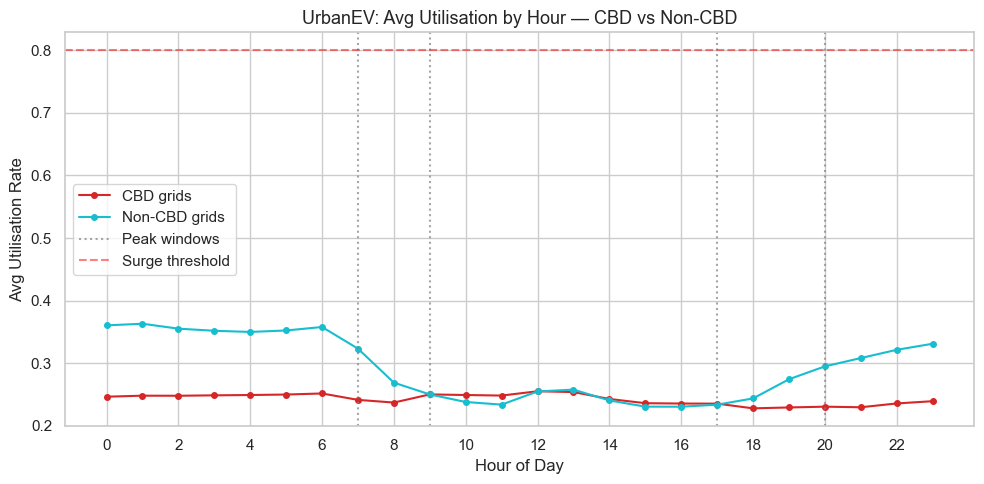

Pricing implication: CBD grids exhibit sharper peaks and higher sustained utilisation,
suggesting location-specific surge pricing can yield higher marginal revenue there.


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

for cbd, label, color in [(1, 'CBD grids', COLORS['peak']), (0, 'Non-CBD grids', COLORS['uev'])]:
    sub = uev[uev['CBD'] == cbd].groupby('hour')['utilization_rate'].mean()
    ax.plot(sub.index, sub.values, marker='o', markersize=4, label=label, color=color)

ax.axvline(7, color='grey', linestyle=':', alpha=0.7)
ax.axvline(9, color='grey', linestyle=':', alpha=0.7)
ax.axvline(17, color='grey', linestyle=':', alpha=0.7)
ax.axvline(20, color='grey', linestyle=':', alpha=0.7, label='Peak windows')
ax.axhline(0.8, color='red', linestyle='--', alpha=0.5, label='Surge threshold')
ax.set_title('UrbanEV: Avg Utilisation by Hour — CBD vs Non-CBD', fontsize=13)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg Utilisation Rate')
ax.set_xticks(range(0, 24, 2))
ax.legend()
plt.tight_layout()
plt.savefig(OUT_FIG / 'eda_cbd_vs_noncbd.png', dpi=150)
plt.show()
print('Pricing implication: CBD grids exhibit sharper peaks and higher sustained utilisation,\nsuggesting location-specific surge pricing can yield higher marginal revenue there.')

## 5. Price–Demand Relationship (UrbanEV Elasticity Preview)

/var/folders/q5/qzzxzszs1194f6vdymzlkyqc0000gn/T/ipykernel_31212/1093422890.py:38: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/q5/qzzxzszs1194f6vdymzlkyqc0000gn/T/ipykernel_31212/1093422890.py:39: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.savefig(OUT_FIG / 'eda_price_elasticity.png', dpi=150)
/Users/prnb/Desktop/socbiz/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


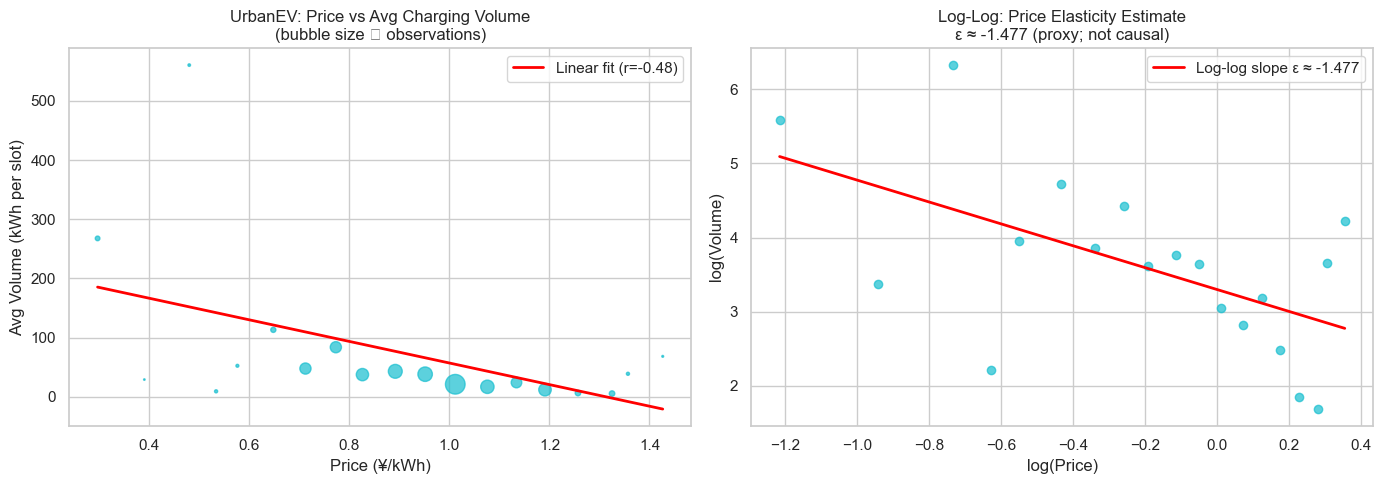

Estimated price elasticity (binned log-log): ε ≈ -1.477
Assumption: this is an associative proxy from UrbanEV ¥ data.
It will parameterise the tariff agent's demand response model.
Caution: this is NOT a causal INR elasticity estimate.


In [6]:
import warnings
from scipy import stats

sub = uev[['price','volume','hour','CBD']].dropna()
sub = sub[(sub['price'] > 0) & (sub['volume'] > 0)]

# Bin prices and compute avg volume per bin
sub['price_bin'] = pd.cut(sub['price'], bins=20)
binned = sub.groupby('price_bin', observed=True).agg(
    mean_price=('price','mean'),
    mean_volume=('volume','mean'),
    n=('volume','count')
).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(binned['mean_price'], binned['mean_volume'],
                s=binned['n']/binned['n'].max()*200, alpha=0.7, color=COLORS['uev'])
m, b, r, p, se = stats.linregress(binned['mean_price'], binned['mean_volume'])
xr = np.linspace(binned['mean_price'].min(), binned['mean_price'].max(), 100)
axes[0].plot(xr, m*xr+b, color='red', lw=2, label=f'Linear fit (r={r:.2f})')
axes[0].set_title('UrbanEV: Price vs Avg Charging Volume\n(bubble size ∝ observations)', fontsize=12)
axes[0].set_xlabel('Price (¥/kWh)')
axes[0].set_ylabel('Avg Volume (kWh per slot)')
axes[0].legend()

# Log-log for elasticity
log_p = np.log(binned['mean_price'])
log_v = np.log(binned['mean_volume'])
m2, b2, r2, p2, _ = stats.linregress(log_p, log_v)
axes[1].scatter(log_p, log_v, alpha=0.7, color=COLORS['uev'])
axes[1].plot(log_p, m2*log_p+b2, color='red', lw=2, label=f'Log-log slope ε ≈ {m2:.3f}')
axes[1].set_title(f'Log-Log: Price Elasticity Estimate\nε ≈ {m2:.3f} (proxy; not causal)', fontsize=12)
axes[1].set_xlabel('log(Price)')
axes[1].set_ylabel('log(Volume)')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_FIG / 'eda_price_elasticity.png', dpi=150)
plt.show()

print(f'Estimated price elasticity (binned log-log): ε ≈ {m2:.3f}')
print('Assumption: this is an associative proxy from UrbanEV ¥ data.')
print('It will parameterise the tariff agent\'s demand response model.')
print('Caution: this is NOT a causal INR elasticity estimate.')

## 6. Long-Run Demand Trend (UrbanEV)

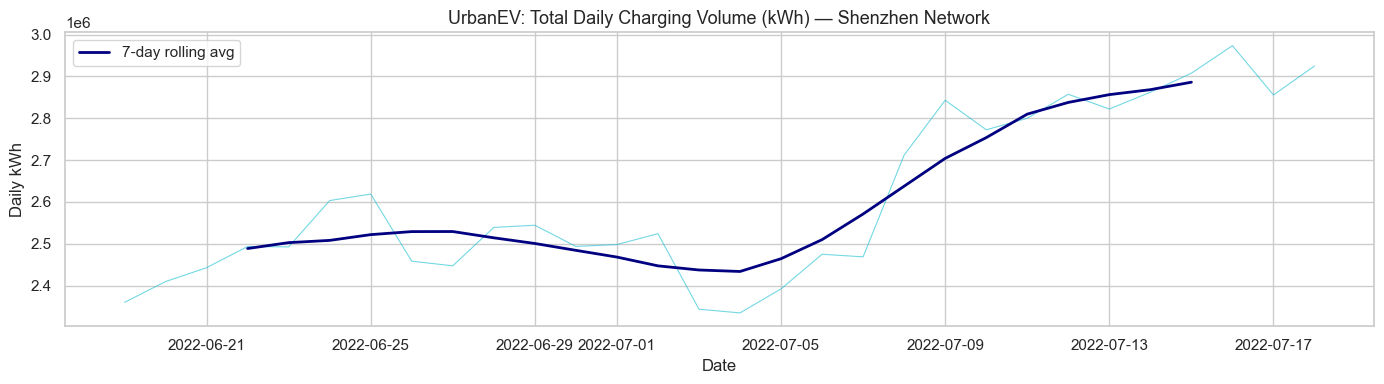

Pricing implication: Upward long-run trend means demand forecasting models must account for non-stationarity.


In [7]:
daily_vol = uev.groupby('datetime')['volume'].sum().reset_index()
daily_vol = daily_vol.set_index('datetime').resample('D')['volume'].sum()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_vol.index, daily_vol.values, alpha=0.6, color=COLORS['uev'], lw=0.8)
roll = daily_vol.rolling(7, center=True).mean()
ax.plot(roll.index, roll.values, color='navy', lw=2, label='7-day rolling avg')
ax.set_title('UrbanEV: Total Daily Charging Volume (kWh) — Shenzhen Network', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Daily kWh')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_FIG / 'eda_daily_volume_trend.png', dpi=150)
plt.show()
print('Pricing implication: Upward long-run trend means demand forecasting models must account for non-stationarity.')

## 7. Top Congested vs Underutilised Stations (ACN)

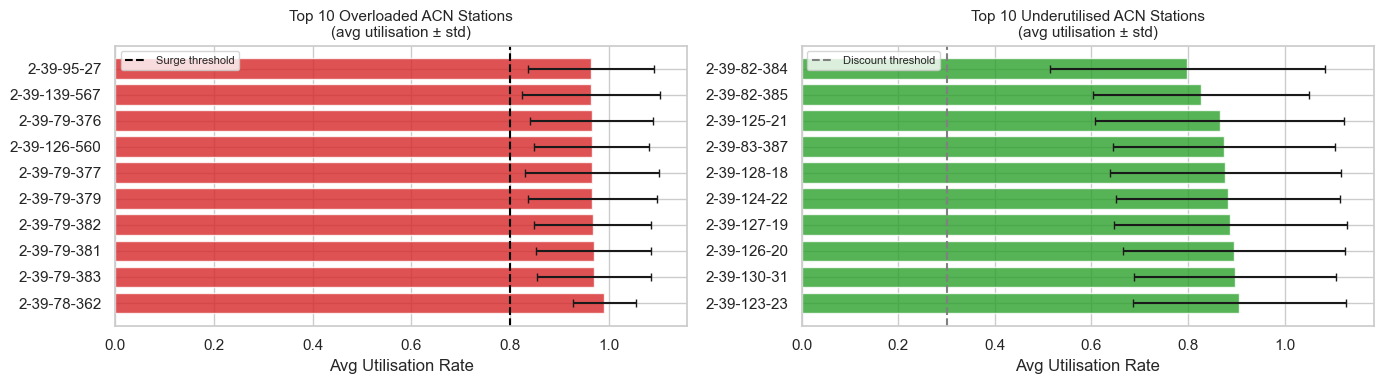

Pricing implication: Persistent over/under-utilisation by station supports station-level tariff differentiation rather than a single network-wide tariff.


In [8]:
station_util = acn_h.groupby('stationID')['utilization_rate'].agg(['mean','std']).sort_values('mean', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

top10 = station_util.head(10)
axes[0].barh(top10.index.astype(str), top10['mean'], xerr=top10['std'],
             color=COLORS['peak'], alpha=0.8, capsize=3)
axes[0].axvline(0.8, color='black', linestyle='--', lw=1.5, label='Surge threshold')
axes[0].set_title('Top 10 Overloaded ACN Stations\n(avg utilisation ± std)', fontsize=11)
axes[0].set_xlabel('Avg Utilisation Rate')
axes[0].legend(fontsize=8)

bot10 = station_util.tail(10)
axes[1].barh(bot10.index.astype(str), bot10['mean'], xerr=bot10['std'],
             color=COLORS['off_peak'], alpha=0.8, capsize=3)
axes[1].axvline(0.3, color='grey', linestyle='--', lw=1.5, label='Discount threshold')
axes[1].set_title('Top 10 Underutilised ACN Stations\n(avg utilisation ± std)', fontsize=11)
axes[1].set_xlabel('Avg Utilisation Rate')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_FIG / 'eda_station_utilisation.png', dpi=150)
plt.show()
print('Pricing implication: Persistent over/under-utilisation by station supports station-level tariff differentiation rather than a single network-wide tariff.')